# GR2M com a nova HydroLab

Notebook com calibração, aquecimento, gap, validação, validação adicional e diagnósticos completos.
(C)opyright Eduardo Martins


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

import HydroLab as hl

sns.set_theme(style="whitegrid", context="notebook")


## HydroLab utilizada neste notebook

Este notebook foi atualizado para a versão atual da **HydroLab**, salva no arquivo `HydroLab.py` na mesma pasta do notebook.

A API utilizada é funcional e direta. Por exemplo:

```python
Qsim = hl.gr2m(P, ETP, X1=500.0, X2=0.8)
```

Os modelos trabalham em lâmina (`mm/dia` ou `mm/mês`, conforme a escala temporal) e não utilizam a área da bacia internamente.


In [2]:
import inspect

print("HydroLab carregada de:", inspect.getfile(hl))
print("Assinatura GR2M:", inspect.signature(hl.gr2m))


HydroLab carregada de: /Users/eduardomartins/Documents/Jupyter/TDP8417/HydroLab.py
Assinatura GR2M: (P, ETP, X1, X2, states=None, return_state=False, return_fluxes=False)


## 1. Leitura dos dados

O arquivo deve conter as colunas:

`DATE, P, ETP, Q`

Para o GR2M:

- `P`: precipitação mensal em mm/mês;
- `ETP`: evapotranspiração potencial mensal em mm/mês;
- `Q`: vazão observada.

Se `Q` já estiver em **mm/mês**, use `Q_UNIT = "mm/month"`.

Se `Q` estiver em **m³/s**, use `Q_UNIT = "m3/s"` e informe a área da bacia em `AREA_KM2`.
A conversão para lâmina é feita antes da modelagem.


In [3]:
dados = "PrEtpQ.csv"

df = pd.read_csv(
    dados,
    sep=",",
    header=0,
    names=["DATE", "P", "ETP", "Q"]
)

df["DATE"] = pd.to_datetime(df["DATE"])

P = df["P"].to_numpy(dtype=float)
ETP = df["ETP"].to_numpy(dtype=float)
Q_original = df["Q"].to_numpy(dtype=float)

len(df)


/var/folders/5r/ypvwx5hn2d7b2kh_cgk8ww8m0000gn/T/ipykernel_24891/4226389278.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE"] = pd.to_datetime(df["DATE"])


384

## 2. Padronização da vazão observada para lâmina

A HydroLab mantém os modelos independentes da área da bacia. Por isso, o GR2M recebe e
retorna somente lâminas em `mm/mês`.

Edite apenas as duas variáveis abaixo conforme o seu conjunto de dados.


In [4]:
# ---------------------------------------------------------
# CONFIGURAÇÃO DO USUÁRIO
# ---------------------------------------------------------

Q_UNIT = "mm/month"     # alternativas: "mm/month" ou "m3/s"
AREA_KM2 = None         # informe a área somente se Q_UNIT == "m3/s"


# ---------------------------------------------------------
# CONVERSÃO PARA A UNIDADE INTERNA DO GR2M: mm/mês
# ---------------------------------------------------------

if Q_UNIT == "mm/month":
    Qobs = Q_original.copy()

elif Q_UNIT == "m3/s":
    if AREA_KM2 is None:
        raise ValueError(
            "Informe AREA_KM2 para converter a vazão observada de m³/s para mm/mês."
        )

    dias_mes = df["DATE"].dt.days_in_month.to_numpy(dtype=float)

    # 1 mm sobre 1 km² = 1000 m³
    Qobs = Q_original * dias_mes * 86400.0 / (AREA_KM2 * 1000.0)

else:
    raise ValueError('Q_UNIT deve ser "mm/month" ou "m3/s".')


## 3. Definição dos períodos experimentais

A série pode ser organizada em até cinco blocos:

**Aquecimento → Calibração → Gap → Validação → Validação adicional**

ou, quando se deseja calibrar no período mais recente:

**Validação adicional → Validação → Gap → Aquecimento → Calibração**

Aquecimento, gap e validação adicional podem ser iguais a zero.  
Se `FRACAO_CAL = 1.0`, toda a série é utilizada na calibração e os demais períodos devem ser zero.

O aquecimento participa da inicialização dos armazenamentos durante a calibração, mas **não entra na função objetivo nem nos índices de desempenho**.


In [5]:
# ============================================================
# CONFIGURAÇÃO DOS PERÍODOS
# ============================================================

FRACAO_AQUEC = 0.05       # warm-up
FRACAO_CAL   = 0.50       # calibração
FRACAO_GAP   = 0.05       # intervalo de segurança
FRACAO_VAL2  = 0.00       # segunda validação (opcional)

# False -> calibração primeiro e validação nos anos mais recentes
# True  -> validação primeiro e calibração nos anos mais recentes
CALIBRACAO_MAIS_RECENTE = False


# ============================================================
# CONSTRUÇÃO DAS MÁSCARAS
# ============================================================

n = len(df)

if n < 2:
    raise ValueError("A série possui dados insuficientes.")

fracoes = {
    "Aquecimento": FRACAO_AQUEC,
    "Calibração": FRACAO_CAL,
    "Gap": FRACAO_GAP,
    "Validação adicional": FRACAO_VAL2,
}

for nome, valor in fracoes.items():
    if valor < 0 or valor > 1:
        raise ValueError(f"{nome}: a fração deve estar entre 0 e 1.")

soma_fixa = FRACAO_AQUEC + FRACAO_CAL + FRACAO_GAP + FRACAO_VAL2

if soma_fixa > 1.0 + 1e-12:
    raise ValueError(
        "A soma FRACAO_AQUEC + FRACAO_CAL + FRACAO_GAP + "
        "FRACAO_VAL2 não pode exceder 1."
    )

FRACAO_VAL = max(0.0, 1.0 - soma_fixa)

# Caso especial: calibração com toda a série
if np.isclose(FRACAO_CAL, 1.0):
    if not (
        np.isclose(FRACAO_AQUEC, 0.0)
        and np.isclose(FRACAO_GAP, 0.0)
        and np.isclose(FRACAO_VAL2, 0.0)
    ):
        raise ValueError(
            "Para calibrar com toda a série (FRACAO_CAL = 1), "
            "use FRACAO_AQUEC = FRACAO_GAP = FRACAO_VAL2 = 0."
        )

n_aquec = int(np.floor(FRACAO_AQUEC * n))
n_cal   = int(np.floor(FRACAO_CAL   * n))
n_gap   = int(np.floor(FRACAO_GAP   * n))
n_val2  = int(np.floor(FRACAO_VAL2  * n))

# A validação principal recebe todo o restante, evitando perda
# de observações por arredondamento.
n_val = n - n_aquec - n_cal - n_gap - n_val2

if n_cal < 2:
    raise ValueError("A calibração precisa conter pelo menos 2 passos.")

if n_val < 0:
    raise ValueError("As frações especificadas excedem o tamanho da série.")

mascara_aquec = np.zeros(n, dtype=bool)
mascara_cal   = np.zeros(n, dtype=bool)
mascara_gap   = np.zeros(n, dtype=bool)
mascara_val   = np.zeros(n, dtype=bool)
mascara_val2  = np.zeros(n, dtype=bool)

if not CALIBRACAO_MAIS_RECENTE:
    # Aquecimento | Calibração | Gap | Validação | Validação 2
    i0 = 0
    i1 = i0 + n_aquec
    i2 = i1 + n_cal
    i3 = i2 + n_gap
    i4 = i3 + n_val
    i5 = i4 + n_val2

    mascara_aquec[i0:i1] = True
    mascara_cal[i1:i2]   = True
    mascara_gap[i2:i3]   = True
    mascara_val[i3:i4]   = True
    mascara_val2[i4:i5]  = True

else:
    # Validação 2 | Validação | Gap | Aquecimento | Calibração
    i0 = 0
    i1 = i0 + n_val2
    i2 = i1 + n_val
    i3 = i2 + n_gap
    i4 = i3 + n_aquec
    i5 = i4 + n_cal

    mascara_val2[i0:i1]  = True
    mascara_val[i1:i2]   = True
    mascara_gap[i2:i3]   = True
    mascara_aquec[i3:i4] = True
    mascara_cal[i4:i5]   = True


def extrair_periodo(mascara):
    """Extrai datas, P, ETP e Qobs de um período; retorna None se vazio."""
    if mascara.sum() == 0:
        return None, None, None, None

    datas = df.loc[mascara, "DATE"].reset_index(drop=True)
    return datas, P[mascara], ETP[mascara], Qobs[mascara]


t_aquec, P_aquec, ETP_aquec, Qobs_aquec = extrair_periodo(mascara_aquec)
t_cal,   P_cal,   ETP_cal,   Qobs_cal   = extrair_periodo(mascara_cal)
t_gap,   P_gap,   ETP_gap,   Qobs_gap   = extrair_periodo(mascara_gap)
t_val,   P_val,   ETP_val,   Qobs_val   = extrair_periodo(mascara_val)
t_val2,  P_val2,  ETP_val2,  Qobs_val2  = extrair_periodo(mascara_val2)


def mostrar_periodo(nome, datas):
    if datas is None or len(datas) == 0:
        print(f"{nome:<23}: não utilizado")
    else:
        print(
            f"{nome:<23}: {datas.iloc[0].date()} a "
            f"{datas.iloc[-1].date()} ({len(datas)} passos)"
        )


print("\nDIVISÃO DA SÉRIE HISTÓRICA")
print("-" * 76)
mostrar_periodo("Aquecimento", t_aquec)
mostrar_periodo("Calibração", t_cal)
mostrar_periodo("Gap", t_gap)
mostrar_periodo("Validação", t_val)
mostrar_periodo("Validação adicional", t_val2)
print("-" * 76)
print(f"Fração efetiva validação: {FRACAO_VAL:.3f}")
print(
    "Posição da calibração:",
    "período mais recente" if CALIBRACAO_MAIS_RECENTE else "período inicial"
)



DIVISÃO DA SÉRIE HISTÓRICA
----------------------------------------------------------------------------
Aquecimento            : 1986-01-31 a 1987-07-31 (19 passos)
Calibração             : 1987-08-31 a 2003-07-31 (192 passos)
Gap                    : 2003-08-31 a 2005-02-28 (19 passos)
Validação              : 2005-03-31 a 2017-12-31 (154 passos)
Validação adicional    : não utilizado
----------------------------------------------------------------------------
Fração efetiva validação: 0.400
Posição da calibração: período inicial


## 4. Funções gráficas

São utilizadas duas rotinas:

1. `plotar_divisao_periodos`: mostra **toda a série**, precipitação e vazão, destacando os períodos de aquecimento, calibração, gap, validação e validação adicional;
2. `diagnostico_hidrologico`: produz o painel diagnóstico completo para qualquer subconjunto da série ou para a série inteira.


In [6]:
def diagnostico_hidrologico(
    datas, Pserie, Qobs_serie, Qsim_serie, *,
    modelo, periodo, parametros,
    unidade_q="mm/mês", unidade_p="mm/mês", salvar=None
):
    datas = pd.to_datetime(pd.Series(datas)).reset_index(drop=True)
    Pserie = np.asarray(Pserie, dtype=float)
    obs = np.asarray(Qobs_serie, dtype=float)
    sim = np.asarray(Qsim_serie, dtype=float)

    valido = np.isfinite(obs) & np.isfinite(sim)
    obs_v, sim_v = obs[valido], sim[valido]

    if obs_v.size < 2:
        raise ValueError("São necessários pelo menos dois pares válidos observado-simulado.")

    resid = sim - obs
    r = np.corrcoef(obs_v, sim_v)[0, 1]

    metricas = {
        "NSE": hl.nse(sim, obs),
        "KGE": hl.kge(sim, obs),
        "KGE'": hl.kgeprime(sim, obs),
        "RMSE": hl.rmse(sim, obs),
        "MARE": hl.mare(sim, obs),
        "PBIAS (%)": hl.pbias(sim, obs),
        "r": r,
    }

    fig = plt.figure(figsize=(17, 11), constrained_layout=True)
    gs = GridSpec(3, 12, figure=fig, height_ratios=[2.2, 1.15, 2.0])

    ax_h    = fig.add_subplot(gs[0, :9])
    ax_info = fig.add_subplot(gs[0, 9:])
    ax_r    = fig.add_subplot(gs[1, :9], sharex=ax_h)
    ax_par  = fig.add_subplot(gs[1, 9:])
    ax_fdc  = fig.add_subplot(gs[2, 0:3])
    ax_sc   = fig.add_subplot(gs[2, 3:6])
    ax_mon  = fig.add_subplot(gs[2, 6:9])
    ax_box  = fig.add_subplot(gs[2, 9:12])

    fig.suptitle(
        f"{modelo} — Diagnóstico do período de {periodo}",
        fontsize=18, fontweight="bold"
    )

    # A) Hidrograma + precipitação invertida
    ax_h.plot(datas, obs, label="Observada", linewidth=1.8)
    ax_h.plot(datas, sim, label=f"Simulada ({modelo})", linewidth=1.5)
    ax_h.set_ylabel(f"Q ({unidade_q})")
    ax_h.set_title(
        "(A) Hidrograma observado vs. simulado",
        loc="left", fontweight="bold"
    )
    ax_h.legend(ncol=2, frameon=False, loc="upper left")

    ax_p = ax_h.twinx()

    # largura baseada no passo temporal, e não no tamanho da amostra
    if len(datas) > 1:
        dt_dias = np.diff(datas.values).astype("timedelta64[D]").astype(int)
        passo_dias = np.nanmedian(dt_dias[dt_dias > 0]) if np.any(dt_dias > 0) else 1
    else:
        passo_dias = 1

    largura_barra = max(0.8, 0.75 * passo_dias)

    ax_p.bar(
        datas, Pserie,
        width=largura_barra,
        alpha=0.30,
        label="Precipitação"
    )

    pmax = np.nanmax(Pserie) if np.isfinite(Pserie).any() else 1.0
    ax_p.set_ylim(max(1.0, pmax * 1.15), 0)
    ax_p.set_ylabel(f"P ({unidade_p})")
    ax_p.grid(False)

    # B) Resíduos
    ax_r.axhline(0, linewidth=1, linestyle="--")
    ax_r.vlines(datas, 0, resid, linewidth=0.9)
    ax_r.set_ylabel(f"Resíduo ({unidade_q})")
    ax_r.set_title(
        "(B) Resíduos da simulação (Qsim − Qobs)",
        loc="left", fontweight="bold"
    )

    # C) Curva de permanência
    def fdc(x):
        x = np.asarray(x, dtype=float)
        x = np.sort(x[np.isfinite(x)])[::-1]
        exc = 100.0 * np.arange(1, len(x) + 1) / (len(x) + 1)
        return exc, x

    po, qo = fdc(obs)
    ps, qs = fdc(sim)

    ax_fdc.plot(po, qo, label="Observada", linewidth=1.8)
    ax_fdc.plot(ps, qs, label="Simulada", linewidth=1.5)

    positivos = np.r_[qo[qo > 0], qs[qs > 0]]
    if positivos.size:
        ax_fdc.set_yscale("log")

    ax_fdc.set_xlabel("Prob. de excedência (%)")
    ax_fdc.set_ylabel(f"Q ({unidade_q})")
    ax_fdc.set_title("(C) Curva de permanência", loc="left", fontweight="bold")
    ax_fdc.legend(frameon=False, fontsize=9)

    # D) Dispersão
    sns.scatterplot(
        x=obs_v, y=sim_v, ax=ax_sc,
        s=28, alpha=0.70, edgecolor=None
    )

    lim0 = min(np.nanmin(obs_v), np.nanmin(sim_v), 0)
    lim1 = max(np.nanmax(obs_v), np.nanmax(sim_v)) * 1.05
    if np.isclose(lim1, lim0):
        lim1 = lim0 + 1.0

    ax_sc.plot(
        [lim0, lim1], [lim0, lim1],
        linestyle="--", linewidth=1.2
    )
    ax_sc.set_xlim(lim0, lim1)
    ax_sc.set_ylim(lim0, lim1)
    ax_sc.set_xlabel(f"Q observada ({unidade_q})")
    ax_sc.set_ylabel(f"Q simulada ({unidade_q})")
    ax_sc.set_title(
        "(D) Dispersão Qsim vs. Qobs",
        loc="left", fontweight="bold"
    )
    ax_sc.text(
        0.04, 0.94,
        f"r = {r:.3f}\nN = {obs_v.size}",
        transform=ax_sc.transAxes,
        va="top"
    )

    # E) Climatologia mensal
    tmp = pd.DataFrame({"data": datas, "obs": obs, "sim": sim})
    clim = tmp.groupby(tmp["data"].dt.month)[["obs", "sim"]].mean()

    ax_mon.plot(clim.index, clim["obs"], marker="o", label="Observada")
    ax_mon.plot(clim.index, clim["sim"], marker="o", label="Simulada")
    ax_mon.set_xticks(range(1, 13))
    ax_mon.set_xlabel("Mês")
    ax_mon.set_ylabel(f"Q média ({unidade_q})")
    ax_mon.set_title("(E) Vazão média mensal", loc="left", fontweight="bold")
    ax_mon.legend(frameon=False, fontsize=9)

    # F) Boxplot
    box = pd.DataFrame({
        "Série": np.repeat(
            ["Observada", "Simulada"],
            [len(obs_v), len(sim_v)]
        ),
        "Q": np.r_[obs_v, sim_v]
    })

    sns.boxplot(
        data=box, x="Série", y="Q",
        ax=ax_box, width=0.55, showfliers=False
    )
    ax_box.set_xlabel("")
    ax_box.set_ylabel(f"Q ({unidade_q})")
    ax_box.set_title(
        "(F) Distribuição das vazões",
        loc="left", fontweight="bold"
    )

    # Quadro de métricas
    ax_info.axis("off")
    linhas = [
        ["NSE", f"{metricas['NSE']:.3f}"],
        ["KGE", f"{metricas['KGE']:.3f}"],
        ["KGE'", f"{metricas['KGE' + chr(39)]:.3f}"],
        ["RMSE", f"{metricas['RMSE']:.3f}"],
        ["MARE", f"{metricas['MARE']:.3f}"],
        ["PBIAS (%)", f"{metricas['PBIAS (%)']:.2f}"],
        ["Correlação (r)", f"{r:.3f}"],
    ]

    # Corrige a chave KGE' da linha acima de forma robusta
    linhas[2][1] = f"{metricas["KGE'"]:.3f}"

    tab = ax_info.table(
        cellText=linhas,
        colLabels=["Índice", "Valor"],
        loc="center",
        cellLoc="center"
    )
    tab.auto_set_font_size(False)
    tab.set_fontsize(10)
    tab.scale(1, 1.45)
    ax_info.set_title(
        "Índices de desempenho",
        fontweight="bold", pad=8
    )

    # Quadro de parâmetros + resíduos
    ax_par.axis("off")

    par_txt = (
        "Parâmetros calibrados\n"
        + "\n".join(
            f"{k} = {v:.6g}" for k, v in parametros.items()
        )
    )

    res_v = resid[np.isfinite(resid)]
    res_txt = (
        f"\n\nResíduos\n"
        f"Média = {np.mean(res_v):.3f}\n"
        f"RMSE = {metricas['RMSE']:.3f}\n"
        f"PBIAS = {metricas['PBIAS (%)']:.2f}%"
    )

    ax_par.text(
        0.05, 0.95,
        par_txt + res_txt,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.6", alpha=0.08)
    )

    sns.despine(fig=fig)

    if salvar:
        fig.savefig(salvar, dpi=300, bbox_inches="tight")

    plt.show()

    return metricas


def plotar_divisao_periodos(
    datas, Pserie, Qobs_serie, Qsim_serie,
    periodos, *,
    modelo="GR2M",
    unidade_q="mm/mês",
    unidade_p="mm/mês",
    salvar=None
):
    """
    Plota toda a série e destaca os períodos experimentais.
    'periodos' é uma lista de tuplas:
    (nome, mascara, cor)
    """
    datas = pd.to_datetime(pd.Series(datas)).reset_index(drop=True)
    Pserie = np.asarray(Pserie, dtype=float)
    obs = np.asarray(Qobs_serie, dtype=float)
    sim = np.asarray(Qsim_serie, dtype=float)

    fig, (ax_p, ax_q) = plt.subplots(
        2, 1,
        figsize=(17, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [1.0, 2.0]},
        constrained_layout=True
    )

    fig.suptitle(
        f"{modelo} — Divisão da série histórica e simulação completa",
        fontsize=17, fontweight="bold"
    )

    # Precipitação
    if len(datas) > 1:
        dt_dias = np.diff(datas.values).astype("timedelta64[D]").astype(int)
        passo_dias = np.nanmedian(dt_dias[dt_dias > 0]) if np.any(dt_dias > 0) else 1
    else:
        passo_dias = 1

    largura_barra = max(0.8, 0.75 * passo_dias)

    ax_p.bar(
        datas, Pserie,
        width=largura_barra,
        alpha=0.35
    )
    ax_p.invert_yaxis()
    ax_p.set_ylabel(f"P ({unidade_p})")
    ax_p.set_title("Precipitação", loc="left", fontweight="bold")

    # Vazões
    ax_q.plot(datas, obs, label="Observada", linewidth=1.7)
    ax_q.plot(datas, sim, label=f"Simulada ({modelo})", linewidth=1.4)
    ax_q.set_ylabel(f"Q ({unidade_q})")
    ax_q.set_xlabel("Tempo")
    ax_q.set_title(
        "Hidrograma e períodos experimentais",
        loc="left", fontweight="bold"
    )
    ax_q.legend(frameon=False, ncol=2, loc="upper left")

    # Faixas dos períodos
    handles_periodos = []

    for nome, mascara, cor in periodos:
        mascara = np.asarray(mascara, dtype=bool)

        if mascara.sum() == 0:
            continue

        idx = np.where(mascara)[0]
        inicio = datas.iloc[idx[0]]
        fim = datas.iloc[idx[-1]]

        # extensão até aproximadamente o próximo passo para preencher
        if len(datas) > 1:
            delta = pd.to_timedelta(passo_dias, unit="D")
        else:
            delta = pd.Timedelta(days=1)

        fim_span = fim + delta

        for ax in (ax_p, ax_q):
            ax.axvspan(
                inicio, fim_span,
                alpha=0.10,
                color=cor,
                zorder=0
            )

        # linha vertical no início de cada bloco
        ax_p.axvline(inicio, color=cor, alpha=0.75, linewidth=1.0)
        ax_q.axvline(inicio, color=cor, alpha=0.75, linewidth=1.0)

        # rótulo dos períodos — abaixo do título "Precipitação"
        meio = inicio + (fim_span - inicio) / 2
        
        ax_p.text(
            meio,
            0.94,  # posição vertical dentro do painel
            nome,
            transform=ax_p.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
            color=cor,
            zorder=10
        )

        handles_periodos.append(
            plt.Line2D([0], [0], color=cor, lw=6, alpha=0.5, label=nome)
        )

    if handles_periodos:
        ax_q.legend(
            handles=ax_q.get_legend_handles_labels()[0] + handles_periodos,
            labels=ax_q.get_legend_handles_labels()[1]
                   + [h.get_label() for h in handles_periodos],
            frameon=False,
            ncol=min(4, 2 + len(handles_periodos)),
            loc="upper center",
            bbox_to_anchor=(0.5, -0.16)
        )

    sns.despine(fig=fig)

    if salvar:
        fig.savefig(salvar, dpi=300, bbox_inches="tight")

    plt.show()


## 5. Calibração do GR2M

Durante cada avaliação do otimizador, o modelo é executado desde o início do **aquecimento** até o fim da **calibração**. Apenas os valores correspondentes à calibração entram no `curve_fit`.

Se o aquecimento for zero, a calibração é executada diretamente.


In [7]:
def gr2m_curvefit_com_aquecimento(dados_entrada_cal, X1, X2):
    """
    Executa warm-up + calibração, mas devolve ao curve_fit
    somente o trecho correspondente à calibração.
    """
    if P_aquec is not None and len(P_aquec) > 0:
        P_exec = np.r_[P_aquec, dados_entrada_cal[:, 0]]
        E_exec = np.r_[ETP_aquec, dados_entrada_cal[:, 1]]

        Q_exec = hl.gr2m(P_exec, E_exec, X1=X1, X2=X2)

        return np.asarray(Q_exec)[len(P_aquec):]

    return hl.gr2m(
        dados_entrada_cal[:, 0],
        dados_entrada_cal[:, 1],
        X1=X1,
        X2=X2
    )


entradas_cal = np.column_stack((P_cal, ETP_cal))

p0 = [10.0, 0.38]
limite_inferior = [0.01, 0.01]
limite_superior = [5000.0, 5.0]

popt, pcov = curve_fit(
    gr2m_curvefit_com_aquecimento,
    entradas_cal,
    Qobs_cal,
    p0=p0,
    bounds=(limite_inferior, limite_superior),
    maxfev=50000
)

X1_cal, X2_cal = popt
parametros_cal = {"X1": X1_cal, "X2": X2_cal}

print(f"X1 calibrado = {X1_cal:.6f}")
print(f"X2 calibrado = {X2_cal:.6f}")

X1 calibrado = 288.689341
X2 calibrado = 0.861710


## 6. Simulação contínua de toda a série

Após a calibração, os parâmetros permanecem fixos e o modelo é executado **uma única vez para toda a série histórica**.  
Os diagnósticos de calibração e validação são então extraídos dessa simulação contínua, preservando a evolução dos armazenamentos entre os períodos.


In [8]:
Qsim_total = np.asarray(
    hl.gr2m(P, ETP, X1=X1_cal, X2=X2_cal),
    dtype=float
)

if len(Qsim_total) != len(df):
    raise ValueError(
        "O número de valores simulados não coincide com o tamanho da série."
    )

# Trechos da simulação contínua
Qsim_cal  = Qsim_total[mascara_cal]
Qsim_val  = Qsim_total[mascara_val]  if mascara_val.sum()  > 0 else None
Qsim_val2 = Qsim_total[mascara_val2] if mascara_val2.sum() > 0 else None

print(f"Simulação completa: {len(Qsim_total)} passos.")


Simulação completa: 384 passos.


## 7. Visão geral — divisão da série histórica

Esta figura mostra toda a série e identifica visualmente os blocos utilizados no experimento.


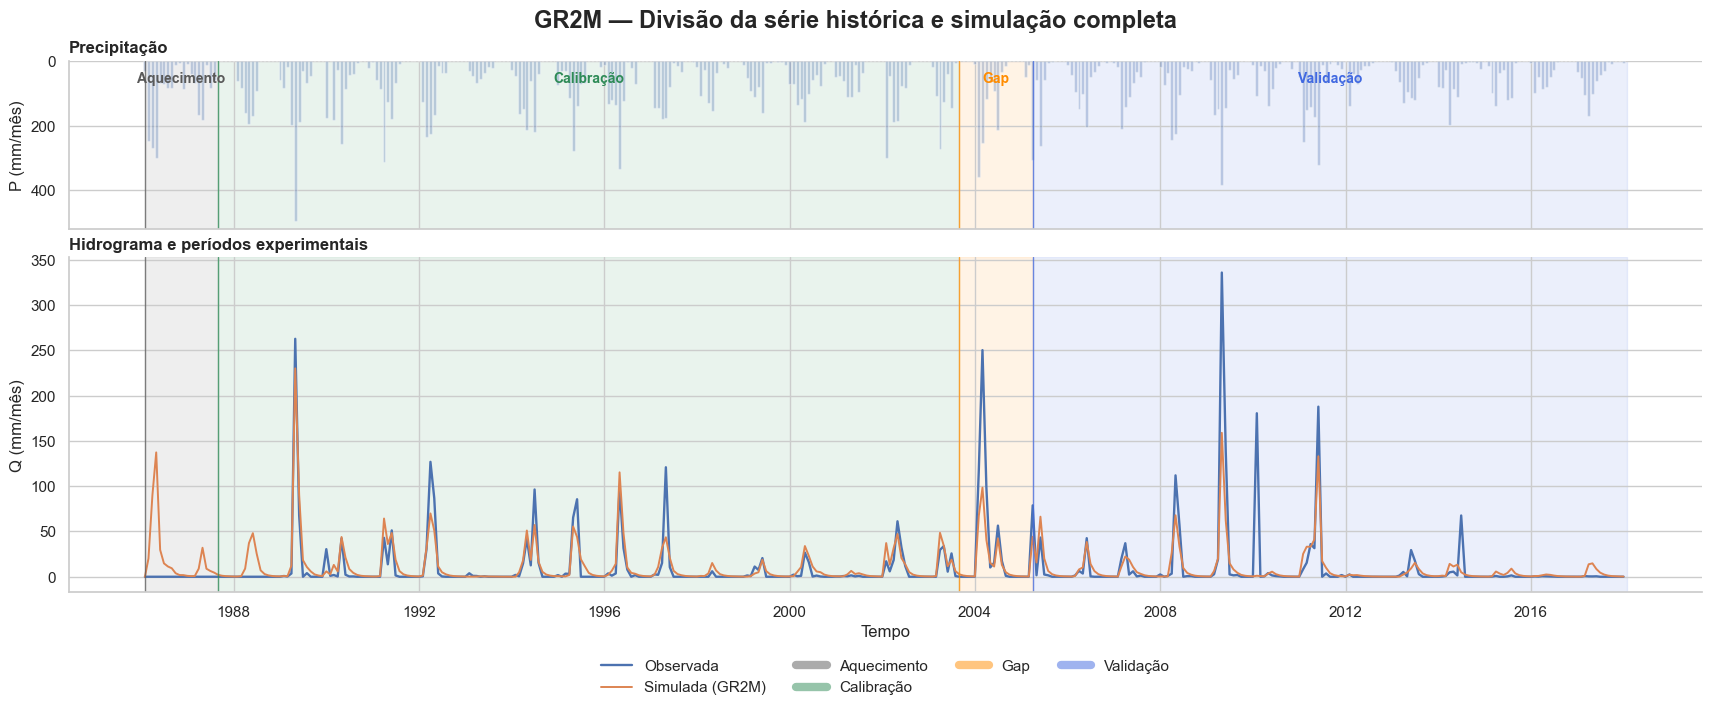

In [9]:
periodos_plot = [
    ("Aquecimento", mascara_aquec, "0.35"),
    ("Calibração", mascara_cal, "seagreen"),
    ("Gap", mascara_gap, "darkorange"),
    ("Validação", mascara_val, "royalblue"),
    ("Validação adicional", mascara_val2, "purple"),
]

plotar_divisao_periodos(
    df["DATE"],
    P,
    Qobs,
    Qsim_total,
    periodos_plot,
    modelo="GR2M",
    unidade_q="mm/mês",
    unidade_p="mm/mês"
)


## 8. Diagnóstico — calibração


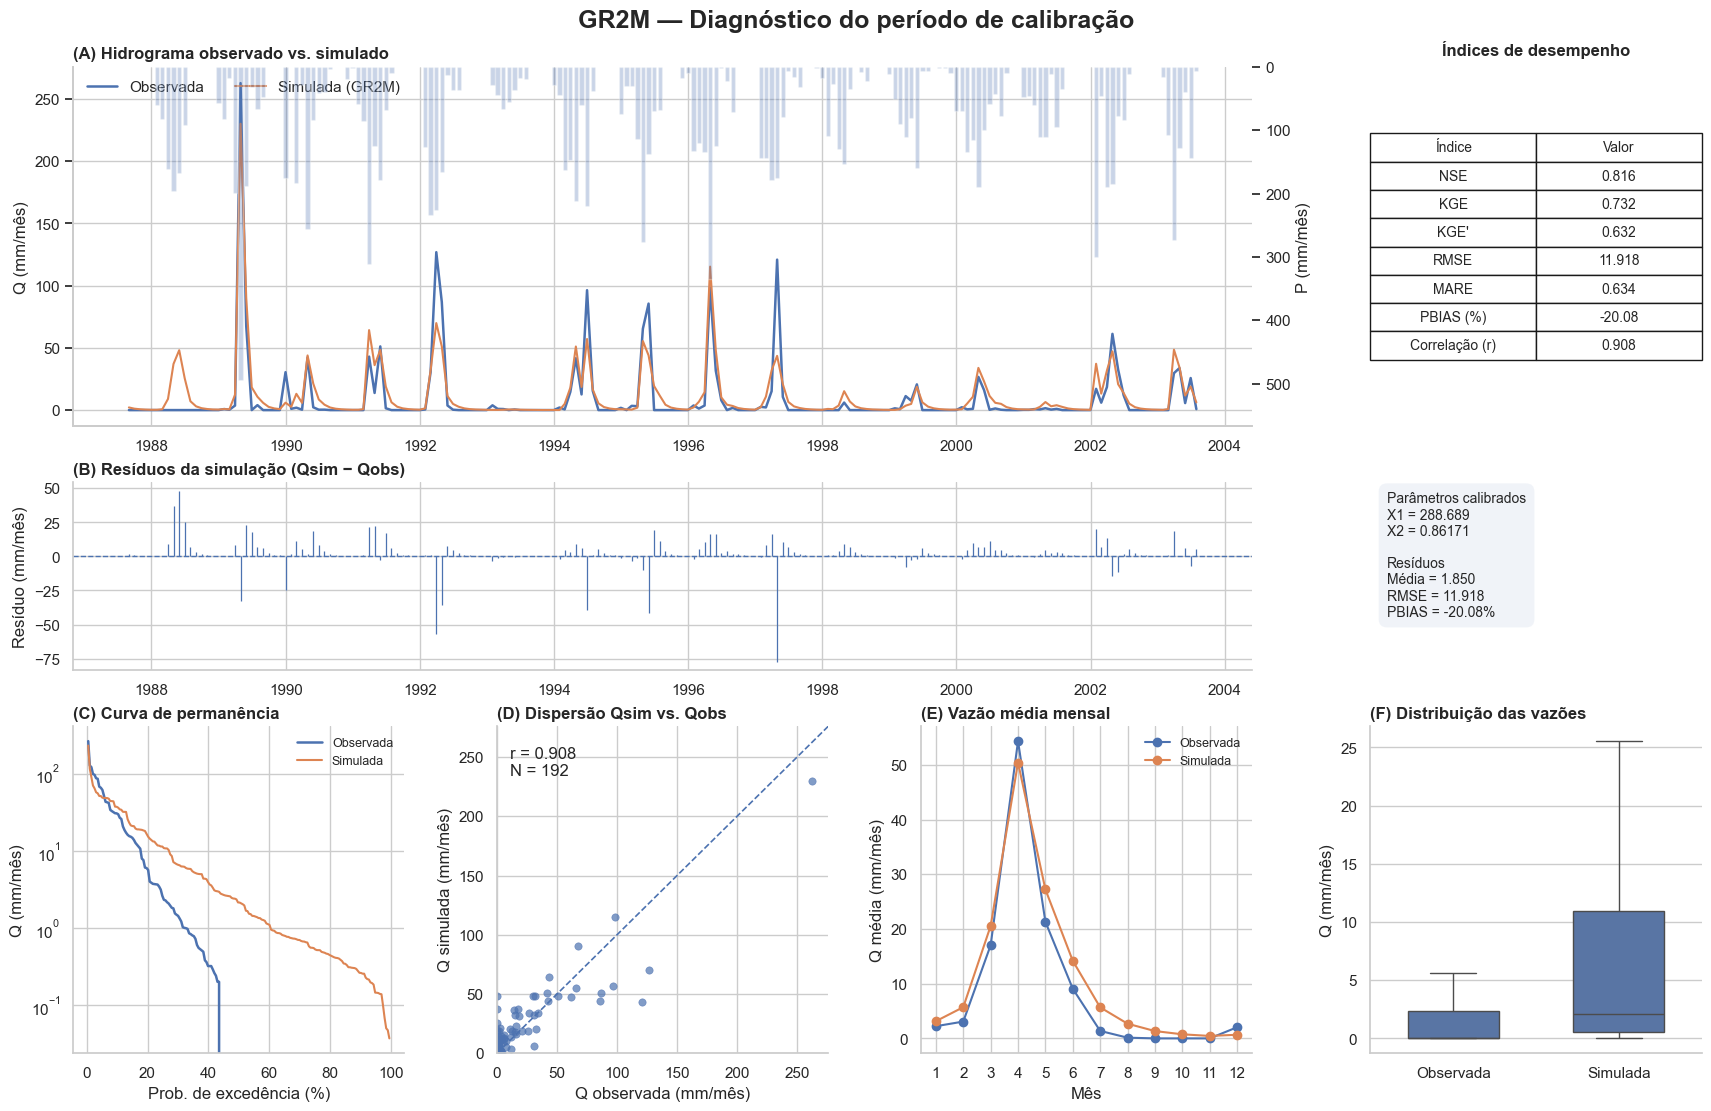

In [10]:
metricas_cal = diagnostico_hidrologico(
    t_cal,
    P_cal,
    Qobs_cal,
    Qsim_cal,
    modelo="GR2M",
    periodo="calibração",
    parametros=parametros_cal,
    unidade_q="mm/mês",
    unidade_p="mm/mês"
)


## 9. Diagnóstico — validação

A figura só é gerada quando existe um período de validação principal.


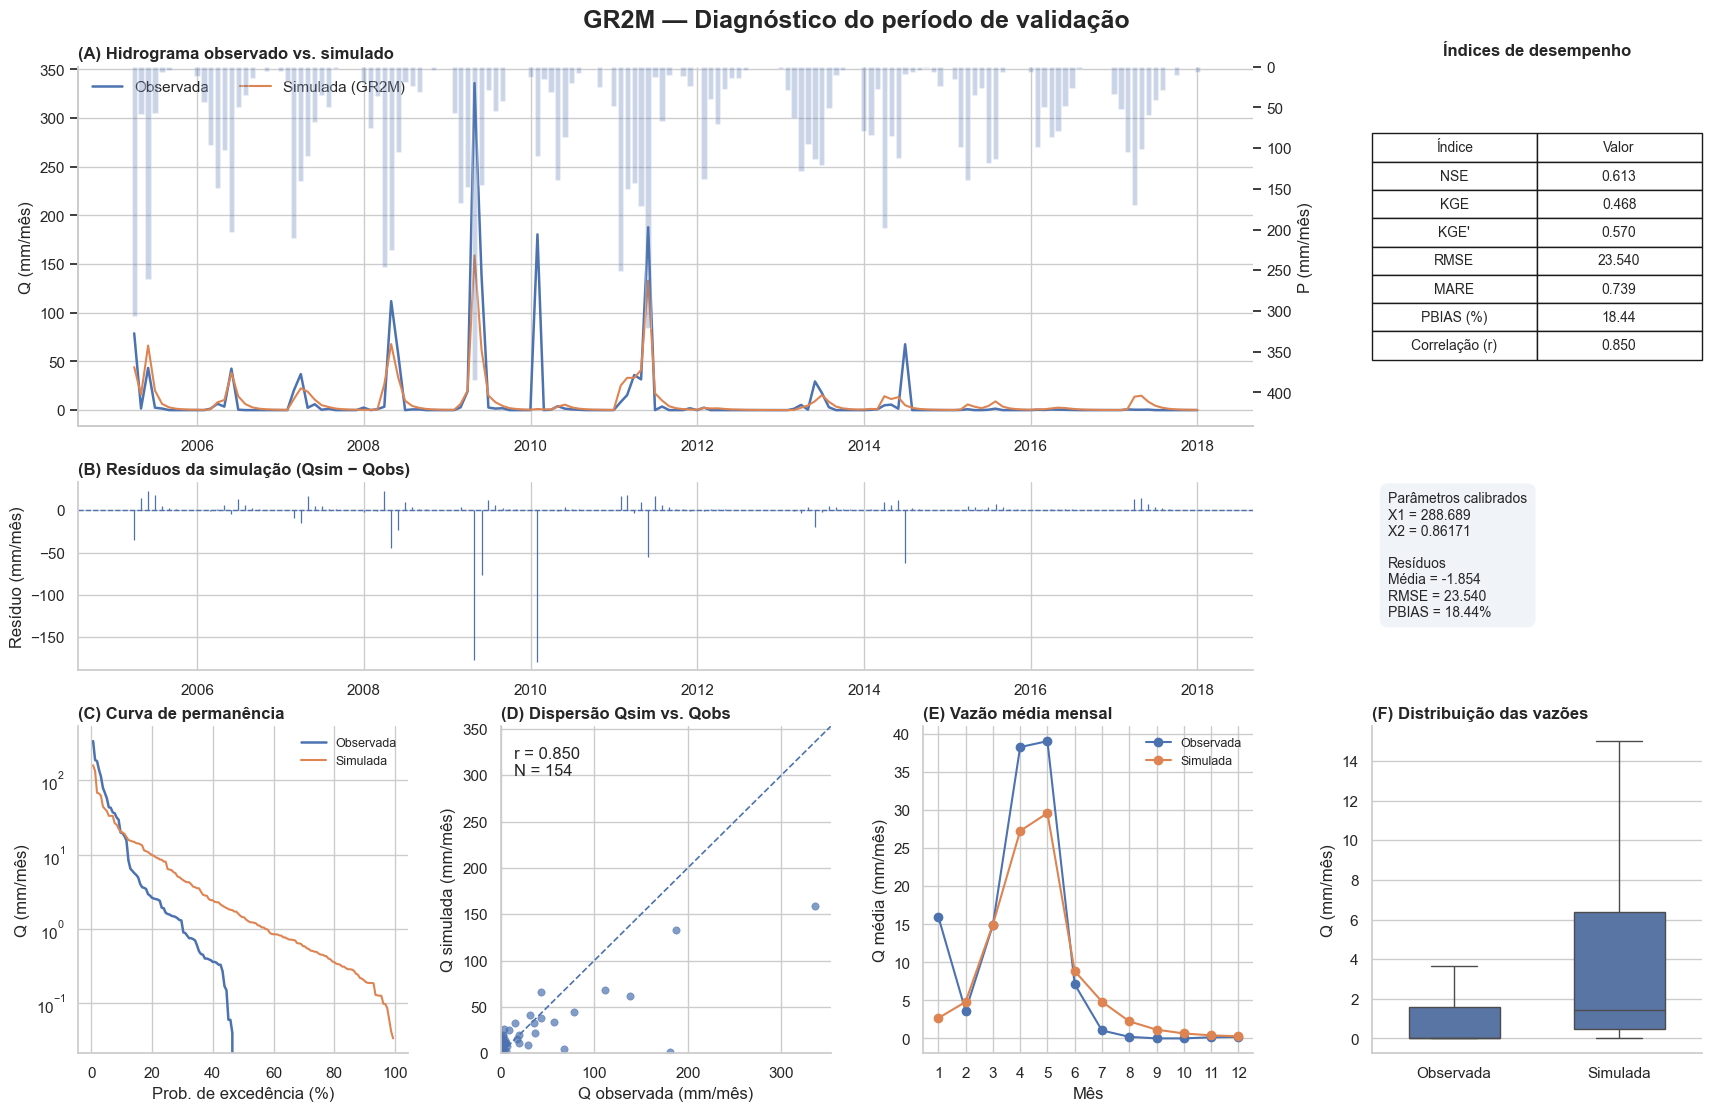

In [11]:
metricas_val = None

if t_val is not None:
    metricas_val = diagnostico_hidrologico(
        t_val,
        P_val,
        Qobs_val,
        Qsim_val,
        modelo="GR2M",
        periodo="validação",
        parametros=parametros_cal,
        unidade_q="mm/mês",
        unidade_p="mm/mês"
    )
else:
    print("Validação principal não utilizada.")


## 10. Diagnóstico — validação adicional

Esta figura só é gerada quando `FRACAO_VAL2 > 0`.


In [12]:
metricas_val2 = None

if t_val2 is not None:
    metricas_val2 = diagnostico_hidrologico(
        t_val2,
        P_val2,
        Qobs_val2,
        Qsim_val2,
        modelo="GR2M",
        periodo="validação adicional",
        parametros=parametros_cal,
        unidade_q="mm/mês",
        unidade_p="mm/mês"
    )
else:
    print("Validação adicional não utilizada.")


Validação adicional não utilizada.


## 11. Diagnóstico — série completa

Este painel utiliza toda a série histórica. Ele é útil para visualizar o comportamento global do modelo, mas seus índices **não substituem** os índices independentes dos períodos de validação.


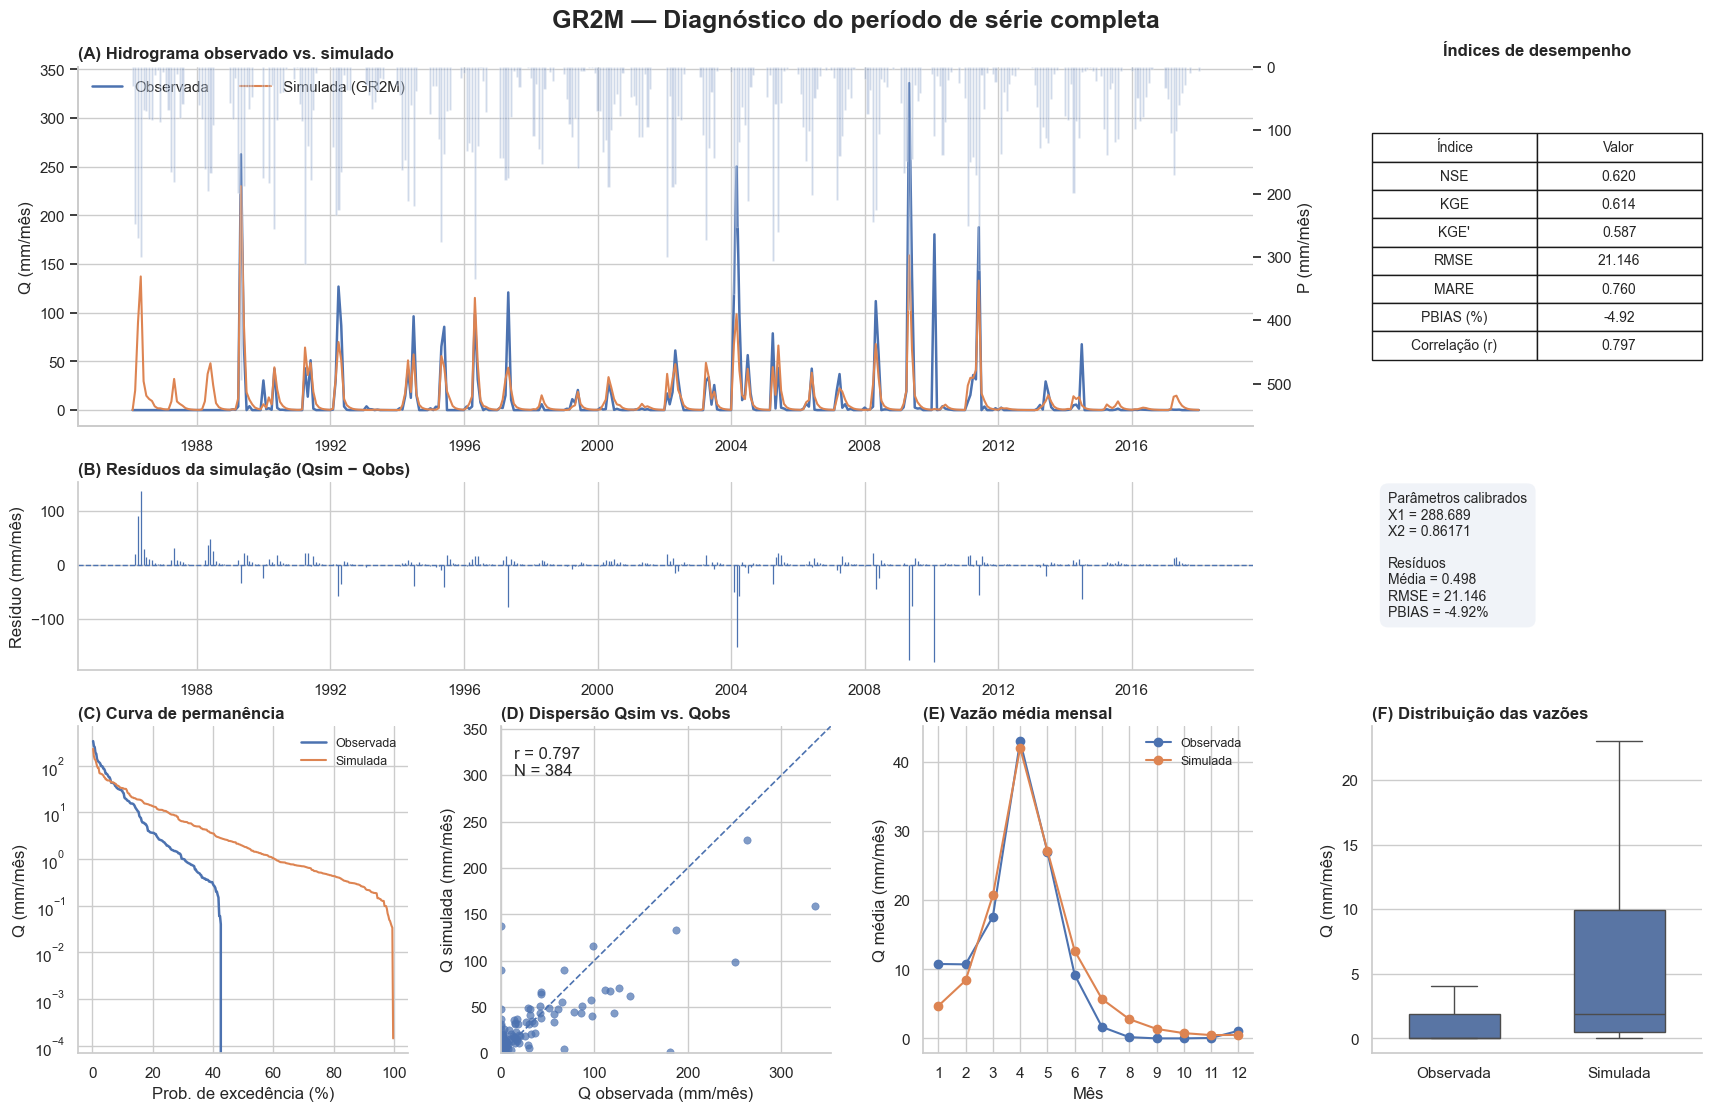

In [13]:
metricas_total = diagnostico_hidrologico(
    df["DATE"],
    P,
    Qobs,
    Qsim_total,
    modelo="GR2M",
    periodo="série completa",
    parametros=parametros_cal,
    unidade_q="mm/mês",
    unidade_p="mm/mês"
)


## 12. Comparação dos índices de desempenho


In [14]:
metricas_periodos = {
    "Calibração": metricas_cal,
    "Série completa": metricas_total,
}

if metricas_val is not None:
    metricas_periodos["Validação"] = metricas_val

if metricas_val2 is not None:
    metricas_periodos["Validação adicional"] = metricas_val2

comparacao = pd.DataFrame(metricas_periodos)
comparacao


,Calibração,Série completa,Validação
NSE,0.816201,0.619762,0.613459
KGE,0.731842,0.613895,0.467565
KGE',0.632411,0.586892,0.570196
RMSE,11.918473,21.145601,23.539581
MARE,0.633943,0.760007,0.739308
PBIAS (%),-20.078700,-4.924536,18.435471
r,0.907862,0.796650,0.849910
